# Diatomic potential

The diatomic potential (two-body potential) energy is the energy of interaction when only two atoms are placed in a vacuum. The value depends on the distance between the atoms.

## Calculate the diatomic potential energy of hydrogen molecule

Using what we have learned so far, let's calculate the diatomic potential energy of hydrogen molecule.

Let's generate hydrogen molecules with various distances between hydrogen atoms, calculate their energies, and plot them.

In [1]:
from ase import Atoms
from ase.visualize import view

import pfp_api_client
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator
from pfp_api_client.pfp.estimator import Estimator, EstimatorCalcMode


estimator = Estimator(model_version="v8.0.0")
calculator = ASECalculator(estimator)

In [2]:
import numpy as np
from tqdm.auto import tqdm

distances = np.linspace(0.3, 6.5, 100)
energy_list = []
for d in tqdm(distances):
    atoms = Atoms("H2", [[0, 0, 0], [0, 0, d]])
    atoms.calc = calculator
    E_pot = atoms.get_potential_energy()
    energy_list.append(E_pot)

energies = np.array(energy_list)

  0%|          | 0/100 [00:00<?, ?it/s]

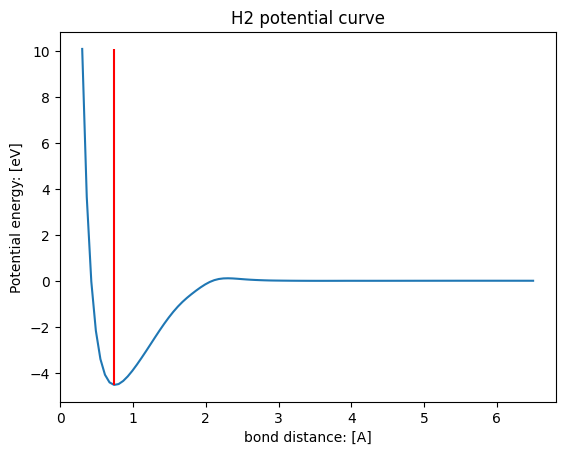

In [3]:
import matplotlib.pyplot as plt


plt.plot(distances, energies)
# H2 bond length = 0.74A
plt.vlines(0.74, np.min(energies), np.max(energies), color="red")
plt.xlabel("bond distance: [A]")
plt.ylabel("Potential energy: [eV]")
plt.title("H2 potential curve")
plt.show()

In [4]:
distances[np.argmin(energies)]

0.7383838383838384

It can be seen that the energy of a hydrogen molecule consisting of the same two hydrogen atoms differs greatly just by changing the interatomic distance. <br/>
Experimentally, it is known that hydrogen molecules are most stable at a bond length of 0.74 A. 
The lowest energies are obtained at the closest positions with the Matlantis calculations.

Thus, it is possible to analyze how materials are structured in nature by calculating energies for various structures.